## Using Zeus for Forecasting

### 1. Load Zeus

In [4]:
# !pip install basicts>=1.1.0
# !hf download GesaltCog/zeus

In [ ]:
from zeus.modeling_zeus import ZeusForPrediction

model = ZeusForPrediction.from_pretrained(
    "GesaltCog/zeus",
    trust_remote_code=True,
    attn_implementation="flash_attention_2",
    device_map="cuda"
    )

### Data

Load the ETTm1 dataset as a demo, you can change it with your own dataset.

In [ ]:
import numpy as np
dataset = np.load(f"datasets/ETTm1/test_data.npy")

In [ ]:
import torch

var = 0
idx = 100
ctx_len = 1024
prediction_length = 256
context = torch.tensor(dataset[idx:idx+ctx_len, var])
target = torch.tensor(dataset[idx+ctx_len:idx+ctx_len+prediction_length, var])

### Inference

In [ ]:
pred, quantile_preds = model.generate(
    context=context,
    prediction_length=prediction_length,
    context_mask = None, # 0 for missing or padding, 1 for valid, default is None
    use_norm=True # Whether to use the instance normalization, default is True
    )

Visualize the results

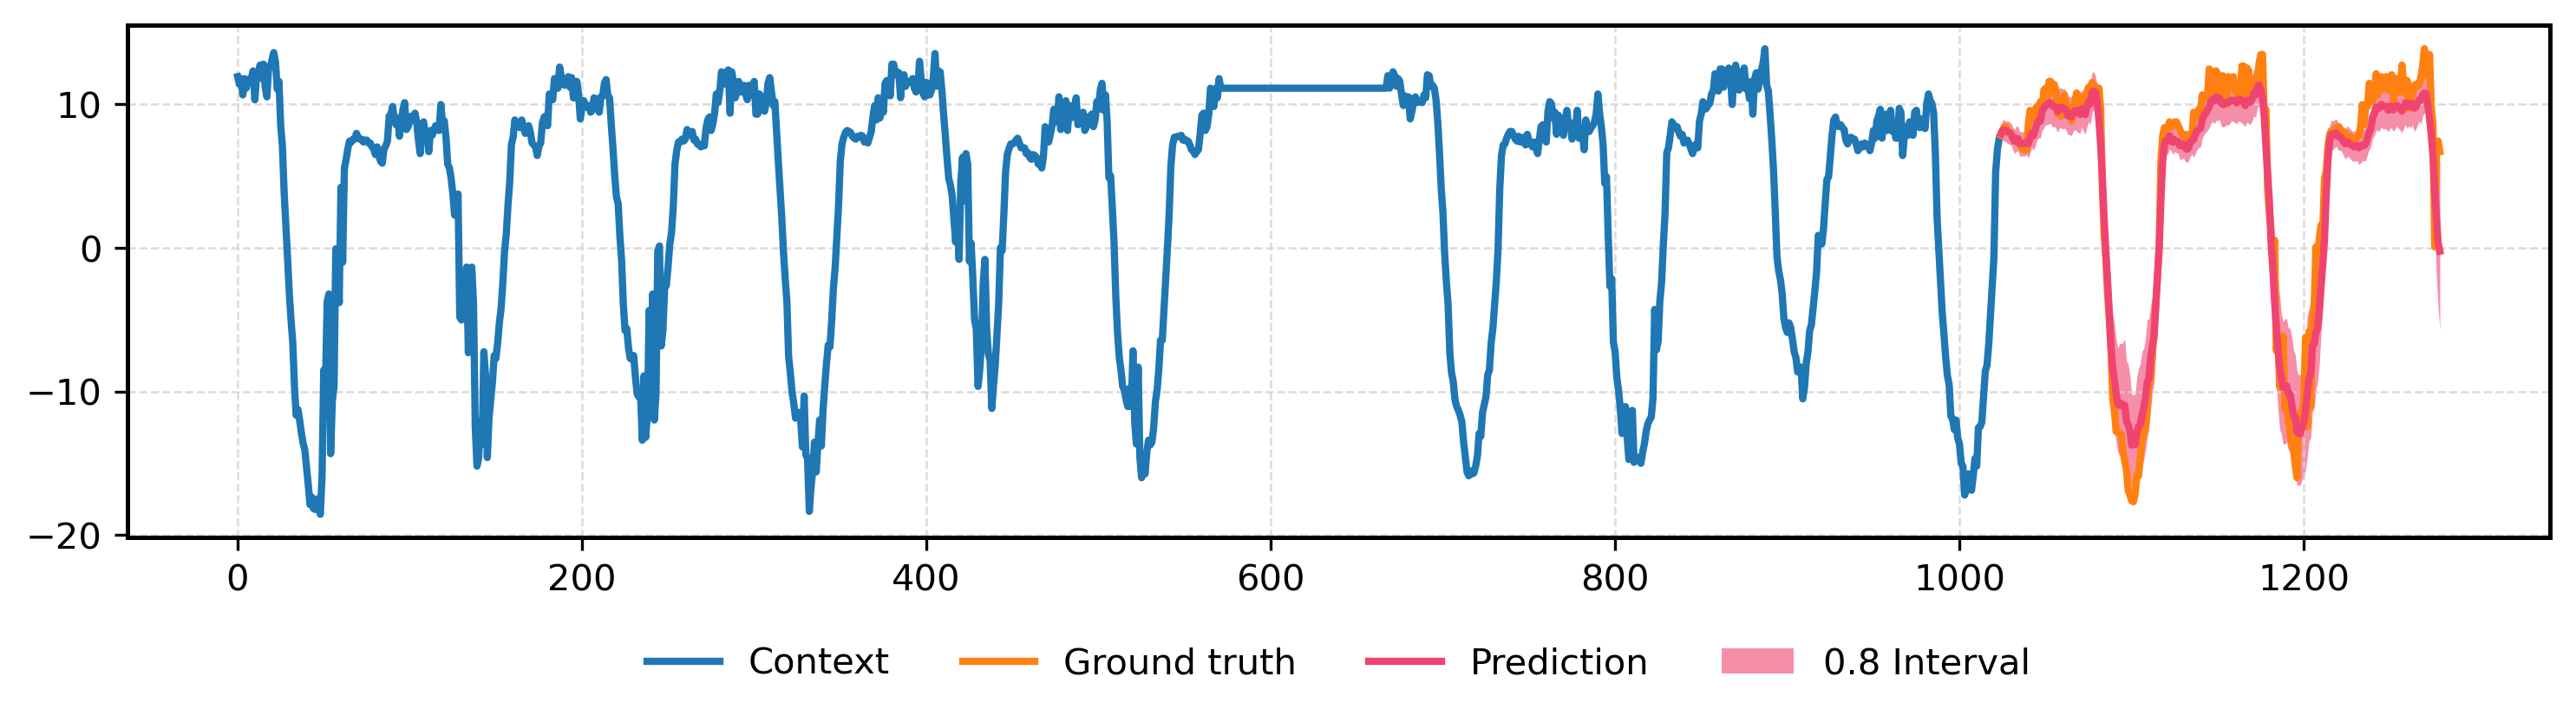

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 2.5), dpi=300)

pred_lo = quantile_preds[..., 1].detach().cpu().numpy()
pred_hi = quantile_preds[..., -2].detach().cpu().numpy()

hist = context.detach().cpu().numpy()
pred_np = pred.detach().cpu().numpy()
tar = target.detach().cpu().numpy()

ax = plt.gca()
ax.grid(
    True,
    which="both",
    axis="both",
    linestyle="--",
    linewidth=0.6,
    color="lightgray",
    alpha=0.8
)

for spine in ax.spines.values():
    spine.set_linewidth(1.2)

color_context = "#007CA7"
color_pred = "#ef4470"
color_gt = "#ff8011"

plt.plot(
    range(ctx_len),
    hist,
    linewidth=2.0,
)

plt.plot(
    range(ctx_len, ctx_len + prediction_length),
    tar,
    color=color_gt,
    linewidth=2.0,
)

plt.plot(
    range(ctx_len, ctx_len + prediction_length),
    pred_np,
    color=color_pred,
    linewidth=2.0,
)

# ---------- 0.8 interval ----------
plt.fill_between(
    range(ctx_len, ctx_len + prediction_length),
    pred_lo,
    pred_hi,
    color=color_pred,
    alpha=0.6,
    linewidth=0
)

plt.tight_layout()
plt.legend(["Context", "Ground truth", "Prediction", "0.8 Interval"],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    frameon=False
)
plt.show()